In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import yfinance as yf
from scipy import stats
from scipy.stats import norm, t as t_dist
import warnings
warnings.filterwarnings('ignore')

# Notebook display settings
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)


# Data Foundation

In [2]:
# ── Portfolio Configuration ──────────────────────────────────────────────────
# We build a realistic multi-asset portfolio: equities + FX + commodity
# This mirrors what a risk analyst would actually monitor

TICKERS = {
    'AAPL':  0.20,   # Apple — US equity
    'MSFT':  0.20,   # Microsoft — US equity
    'GOOGL': 0.15,   # Alphabet — US equity
    '^GSPC': 0.15,   # S&P 500 index
    'EURUSD=X': 0.15, # EUR/USD — FX
    'GC=F':  0.15,   # Gold futures — commodity
}

START_DATE  = '2018-01-01'
END_DATE    = '2024-01-01'
PORTFOLIO_VALUE = 10_000_000  # £10 million notional

print(f"Portfolio: {len(TICKERS)} assets")
print(f"Period   : {START_DATE} → {END_DATE}")
print(f"Notional : £{PORTFOLIO_VALUE:,.0f}")
print(f"\nWeights  :")
for ticker, weight in TICKERS.items():
    print(f"  {ticker:<12} {weight*100:.0f}%")

Portfolio: 6 assets
Period   : 2018-01-01 → 2024-01-01
Notional : £10,000,000

Weights  :
  AAPL         20%
  MSFT         20%
  GOOGL        15%
  ^GSPC        15%
  EURUSD=X     15%
  GC=F         15%


In [3]:
# ── Fetch price data ─────────────────────────────────────────────────────────
print("Downloading price data...")

raw_prices = yf.download(
    tickers=list(TICKERS.keys()),
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False
)['Close']

# Drop any columns with excessive missing data (>5%)
missing_pct = raw_prices.isnull().mean()
dropped = missing_pct[missing_pct > 0.05].index.tolist()
if dropped:
    print(f"  Dropping {dropped} — too many missing values")
    raw_prices = raw_prices.drop(columns=dropped)

# Forward-fill then drop remaining NaNs (handles market holidays)
prices = raw_prices.ffill().dropna()

print(f"\n✓ Clean price data: {prices.shape[0]} trading days × {prices.shape[1]} assets")
print(f"  Date range: {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"\nSample (last 5 rows):")
print(prices.tail())


✓ Clean price data: 1564 trading days × 6 assets
  Date range: 2018-01-02 → 2023-12-29

Sample (last 5 rows):
Ticker         AAPL  EURUSD=X      GC=F    GOOGL     MSFT     ^GSPC
Date                                                               
2023-12-25 191.6095    1.1027 2057.1001 140.3302 368.2366 4754.6299
2023-12-26 191.0651    1.1020 2058.2000 140.3600 368.3153 4774.7500
2023-12-27 191.1641    1.1043 2081.8999 139.2193 367.7353 4781.5801
2023-12-28 191.5897    1.1109 2073.8999 139.0805 368.9248 4783.3501
2023-12-29 190.5505    1.1068 2062.3999 138.5449 369.6719 4769.8301


In [4]:
# ── Compute log returns ───────────────────────────────────────────────────────
log_returns = np.log(prices / prices.shift(1)).dropna()

# Align weights to actual tickers after cleaning
weights = np.array([TICKERS[t] for t in log_returns.columns])
weights = weights / weights.sum()

# Portfolio daily log return
portfolio_returns = log_returns.dot(weights)

print(f"✓ Log returns computed: {log_returns.shape}")
print(f"\nPortfolio return summary:")
print(portfolio_returns.describe().rename('Daily log return').to_frame())

✓ Log returns computed: (1563, 6)

Portfolio return summary:
       Daily log return
count         1563.0000
mean             0.0006
std              0.0115
min             -0.1005
25%             -0.0045
50%              0.0008
75%              0.0065
max              0.0700


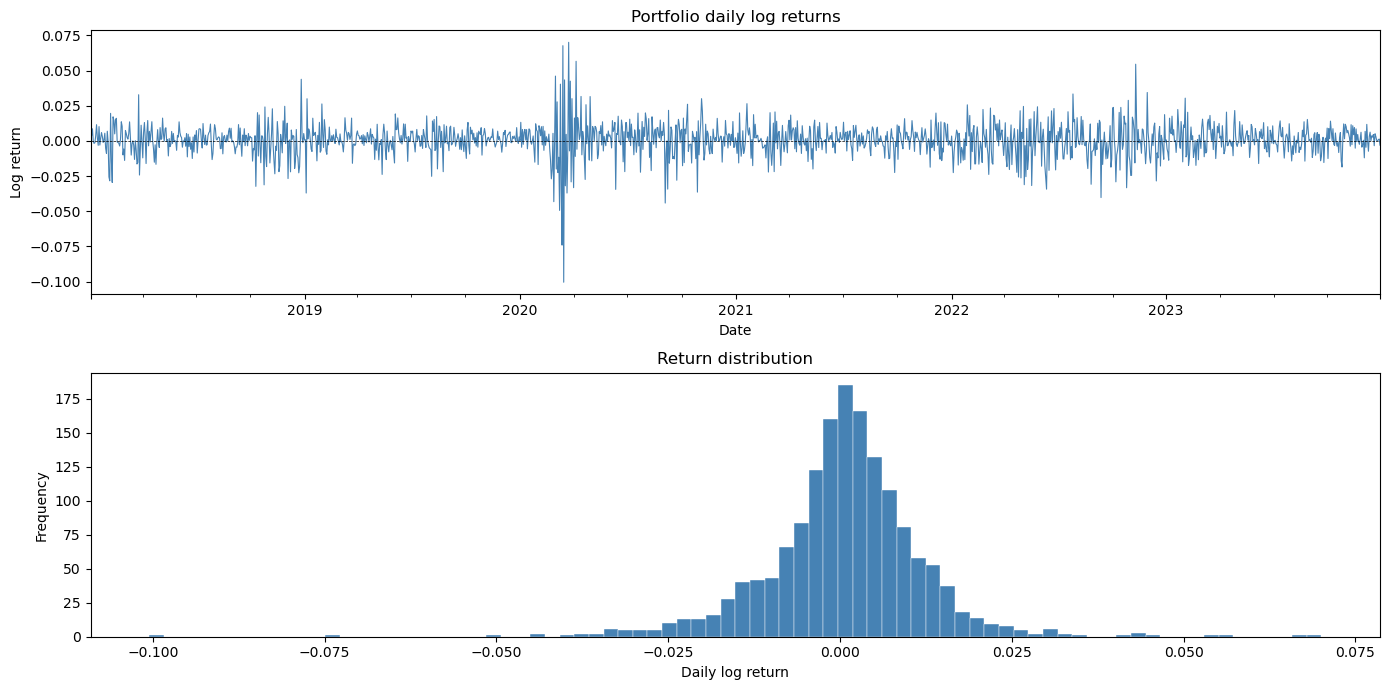

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

portfolio_returns.plot(ax=axes[0], color='steelblue', linewidth=0.8,
                       title='Portfolio daily log returns')
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].set_ylabel('Log return')

portfolio_returns.plot.hist(ax=axes[1], bins=80, color='steelblue',
                            edgecolor='white', linewidth=0.3,
                            title='Return distribution')
axes[1].set_xlabel('Daily log return')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


# Historical Var & CVaR 

In [6]:
# ── Historical VaR & CVaR ─────────────────────────────────────────────────────
# Method: sort all past returns, find the loss at the confidence level cutoff
# No distribution assumption — uses the actual empirical data
# CVaR (Expected Shortfall) = average of all losses BEYOND the VaR threshold

def historical_var_cvar(returns, confidence_levels=[0.95, 0.99], portfolio_value=PORTFOLIO_VALUE):
    """
    Compute Historical VaR and CVaR at multiple confidence levels.
    
    Parameters
    ----------
    returns          : pd.Series of daily log returns
    confidence_levels: list of confidence levels e.g. [0.95, 0.99]
    portfolio_value  : notional portfolio value in £
    
    Returns
    -------
    pd.DataFrame with VaR and CVaR in % and £ terms
    """
    results = []
    
    for cl in confidence_levels:
        # VaR: the loss not exceeded (1-cl)% of the time
        var_pct  = np.percentile(returns, (1 - cl) * 100)
        
        # CVaR: mean of all returns worse than VaR (the tail average)
        cvar_pct = returns[returns <= var_pct].mean()
        
        results.append({
            'Confidence Level' : f'{cl*100:.0f}%',
            'VaR (%)'          : f'{var_pct*100:.3f}%',
            'VaR (£)'          : f'£{abs(var_pct) * portfolio_value:,.0f}',
            'CVaR (%)'         : f'{cvar_pct*100:.3f}%',
            'CVaR (£)'         : f'£{abs(cvar_pct) * portfolio_value:,.0f}',
        })
    
    return pd.DataFrame(results)


results_historical = historical_var_cvar(portfolio_returns)
print("Historical VaR & CVaR Results")
print("=" * 55)
print(results_historical.to_string(index=False))

Historical VaR & CVaR Results
Confidence Level VaR (%)  VaR (£) CVaR (%) CVaR (£)
             95% -1.762% £176,164  -2.732% £273,175
             99% -3.210% £320,992  -4.368% £436,781


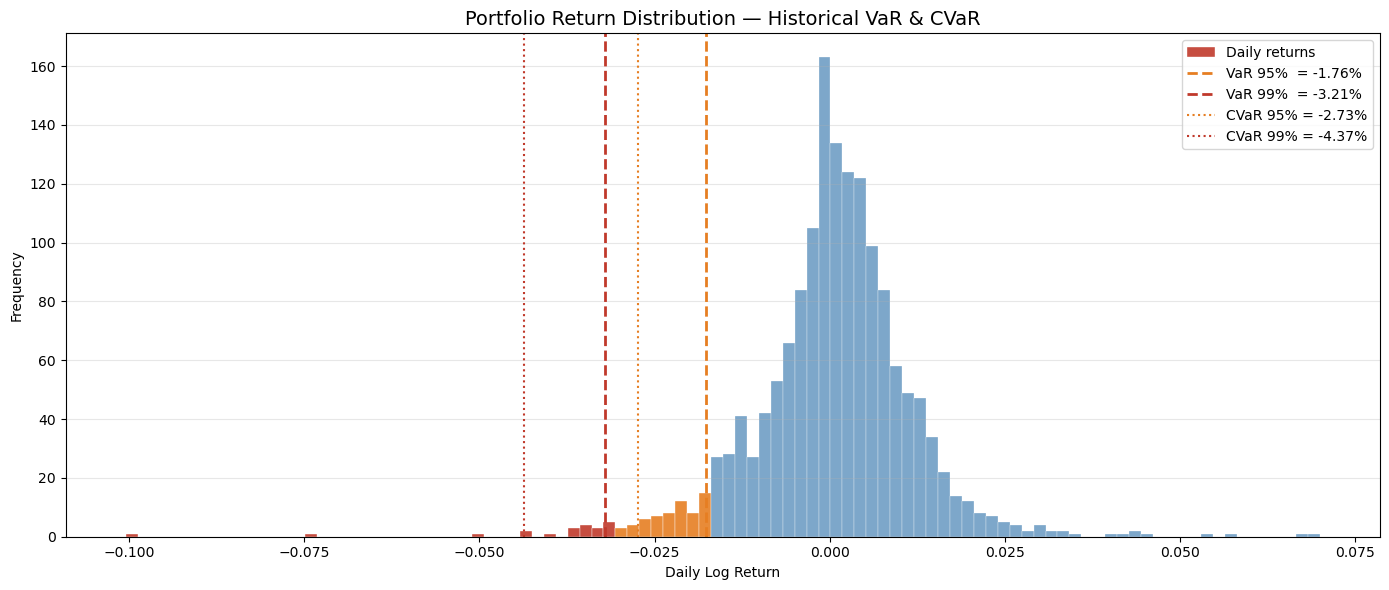


Key numbers (£10m portfolio):
  VaR  95% → on a bad day (1 in 20),  expect to lose at least  £     176,164
  VaR  99% → on a bad day (1 in 100), expect to lose at least  £     320,992
  CVaR 95% → when things go bad,      average loss is around   £     273,175
  CVaR 99% → in the worst 1% of days, average loss is around   £     436,781


In [7]:
# ── Plot return distribution with VaR / CVaR marked ──────────────────────────

var_95  = np.percentile(portfolio_returns, 5)
var_99  = np.percentile(portfolio_returns, 1)
cvar_95 = portfolio_returns[portfolio_returns <= var_95].mean()
cvar_99 = portfolio_returns[portfolio_returns <= var_99].mean()

fig, ax = plt.subplots(figsize=(14, 6))

# Full return distribution
n, bins, patches = ax.hist(portfolio_returns, bins=100,
                            color='steelblue', edgecolor='white',
                            linewidth=0.3, alpha=0.7,
                            label='Daily returns')

# Colour the tail red beyond 99% VaR
for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge <= var_99:
        patch.set_facecolor('#c0392b')
        patch.set_alpha(0.9)
    elif left_edge <= var_95:
        patch.set_facecolor('#e67e22')
        patch.set_alpha(0.9)

# VaR vertical lines
ax.axvline(var_95,  color='#e67e22', linewidth=2,
           linestyle='--', label=f'VaR 95%  = {var_95*100:.2f}%')
ax.axvline(var_99,  color='#c0392b', linewidth=2,
           linestyle='--', label=f'VaR 99%  = {var_99*100:.2f}%')
ax.axvline(cvar_95, color='#e67e22', linewidth=1.5,
           linestyle=':',  label=f'CVaR 95% = {cvar_95*100:.2f}%')
ax.axvline(cvar_99, color='#c0392b', linewidth=1.5,
           linestyle=':',  label=f'CVaR 99% = {cvar_99*100:.2f}%')

ax.set_title('Portfolio Return Distribution — Historical VaR & CVaR', fontsize=14)
ax.set_xlabel('Daily Log Return')
ax.set_ylabel('Frequency')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nKey numbers (£10m portfolio):")
print(f"  VaR  95% → on a bad day (1 in 20),  expect to lose at least  £{abs(var_95)*PORTFOLIO_VALUE:>12,.0f}")
print(f"  VaR  99% → on a bad day (1 in 100), expect to lose at least  £{abs(var_99)*PORTFOLIO_VALUE:>12,.0f}")
print(f"  CVaR 95% → when things go bad,      average loss is around   £{abs(cvar_95)*PORTFOLIO_VALUE:>12,.0f}")
print(f"  CVaR 99% → in the worst 1% of days, average loss is around   £{abs(cvar_99)*PORTFOLIO_VALUE:>12,.0f}")

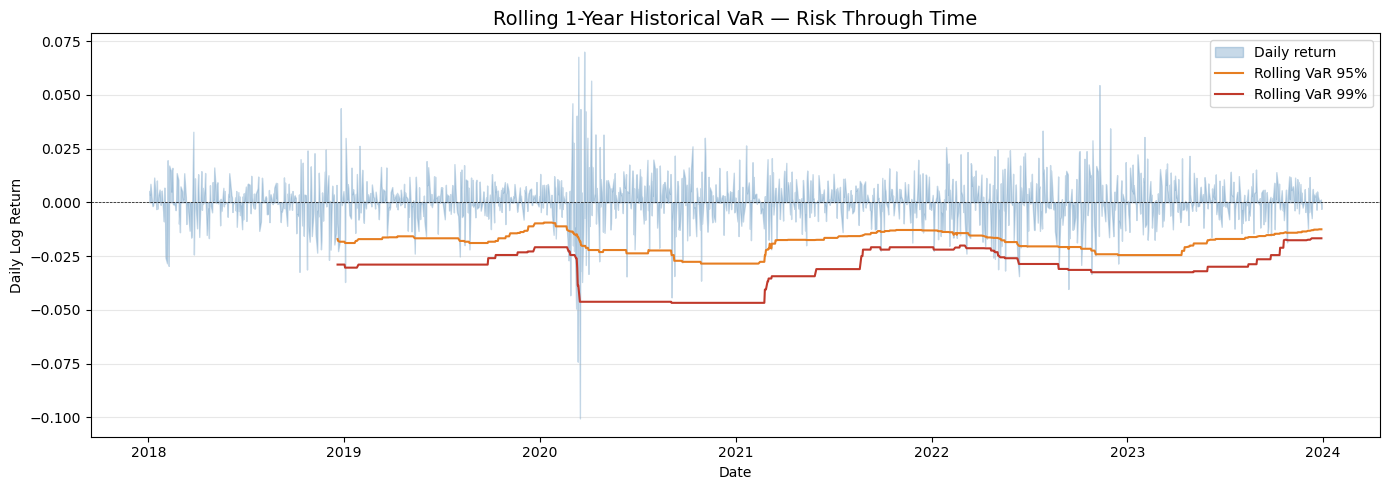

In [8]:
# ── Rolling 1-year Historical VaR ────────────────────────────────────────────
# Static VaR assumes risk is constant — it isn't
# Rolling VaR shows how the risk profile evolved (e.g. spikes in 2020)

WINDOW = 252  # 1 trading year

rolling_var_95 = portfolio_returns.rolling(WINDOW).quantile(0.05)
rolling_var_99 = portfolio_returns.rolling(WINDOW).quantile(0.01)

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(portfolio_returns.index, portfolio_returns,
                alpha=0.3, color='steelblue', label='Daily return')
ax.plot(rolling_var_95.index, rolling_var_95,
        color='#e67e22', linewidth=1.5, label='Rolling VaR 95%')
ax.plot(rolling_var_99.index, rolling_var_99,
        color='#c0392b', linewidth=1.5, label='Rolling VaR 99%')

ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('Rolling 1-Year Historical VaR — Risk Through Time', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Daily Log Return')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



# Parametric VaR

In [9]:
# ── Parametric VaR — Normal Distribution ─────────────────────────────────────
# Assumes portfolio returns ~ Normal(μ, σ)
# VaR = μ - z * σ  where z is the confidence level z-score
# This is the classic variance-covariance approach used by most risk desks

def parametric_var_normal(returns, confidence_levels=[0.95, 0.99], 
                           portfolio_value=PORTFOLIO_VALUE):
    """
    Compute VaR and CVaR assuming normally distributed returns.
    
    Parameters
    ----------
    returns           : pd.Series of daily log returns
    confidence_levels : list of confidence levels
    portfolio_value   : notional portfolio value in £
    
    Returns
    -------
    pd.DataFrame of results
    """
    mu    = returns.mean()
    sigma = returns.std()
    
    results = []
    
    for cl in confidence_levels:
        z        = norm.ppf(1 - cl)           # negative z-score for loss side
        var_pct  = mu + z * sigma             # VaR in return terms
        
        # CVaR under normality has a closed-form solution
        cvar_pct = mu - sigma * (norm.pdf(norm.ppf(1 - cl)) / (1 - cl))
        
        results.append({
            'Confidence Level' : f'{cl*100:.0f}%',
            'Mean daily return': f'{mu*100:.4f}%',
            'Daily volatility' : f'{sigma*100:.4f}%',
            'VaR (%)'          : f'{var_pct*100:.3f}%',
            'VaR (£)'          : f'£{abs(var_pct) * portfolio_value:,.0f}',
            'CVaR (%)'         : f'{cvar_pct*100:.3f}%',
            'CVaR (£)'         : f'£{abs(cvar_pct) * portfolio_value:,.0f}',
        })
    
    return pd.DataFrame(results)


results_normal = parametric_var_normal(portfolio_returns)
print("Parametric VaR & CVaR — Normal Distribution")
print("=" * 65)
print(results_normal.to_string(index=False))

Parametric VaR & CVaR — Normal Distribution
Confidence Level Mean daily return Daily volatility VaR (%)  VaR (£) CVaR (%) CVaR (£)
             95%           0.0578%          1.1533% -1.839% £183,908  -2.321% £232,098
             99%           0.0578%          1.1533% -2.625% £262,502  -3.016% £301,582


In [10]:
# ── Parametric VaR — Student's t-Distribution ────────────────────────────────
# Financial returns have FATTER tails than a normal distribution
# The t-distribution captures this — it has a degrees of freedom (df) parameter
# Lower df = fatter tails = more conservative VaR estimate
# We fit df to the actual data rather than assuming it

def parametric_var_t(returns, confidence_levels=[0.95, 0.99],
                     portfolio_value=PORTFOLIO_VALUE):
    """
    Compute VaR and CVaR using a fitted Student's t-distribution.
    Fatter tails than normal — more realistic for financial returns.
    """
    # Fit t-distribution to the data — let it find the best df
    df_fit, loc_fit, scale_fit = t_dist.fit(returns, floc=returns.mean())
    
    results = []
    
    for cl in confidence_levels:
        var_pct  = t_dist.ppf(1 - cl, df=df_fit, loc=loc_fit, scale=scale_fit)
        
        # CVaR under t-distribution
        alpha    = 1 - cl
        cvar_pct = loc_fit - scale_fit * (
            t_dist.pdf(t_dist.ppf(alpha, df=df_fit), df=df_fit) / alpha
        ) * ((df_fit + t_dist.ppf(alpha, df=df_fit)**2) / (df_fit - 1))
        
        results.append({
            'Confidence Level'  : f'{cl*100:.0f}%',
            'Fitted df'         : f'{df_fit:.2f}',
            'VaR (%)'           : f'{var_pct*100:.3f}%',
            'VaR (£)'           : f'£{abs(var_pct) * portfolio_value:,.0f}',
            'CVaR (%)'          : f'{cvar_pct*100:.3f}%',
            'CVaR (£)'          : f'£{abs(cvar_pct) * portfolio_value:,.0f}',
        })
    
    return pd.DataFrame(results)


results_t = parametric_var_t(portfolio_returns)
print("Parametric VaR & CVaR — Student's t-Distribution")
print("=" * 65)
print(results_t.to_string(index=False))
print(f"\nNote: lower degrees of freedom = fatter tails = higher VaR")
print(f"If df < 10, returns have meaningfully fatter tails than normal")

Parametric VaR & CVaR — Student's t-Distribution
Confidence Level Fitted df VaR (%)  VaR (£) CVaR (%) CVaR (£)
             95%      3.24 -1.657% £165,693  -2.683% £268,296
             99%      3.24 -3.156% £315,583  -4.739% £473,898

Note: lower degrees of freedom = fatter tails = higher VaR
If df < 10, returns have meaningfully fatter tails than normal


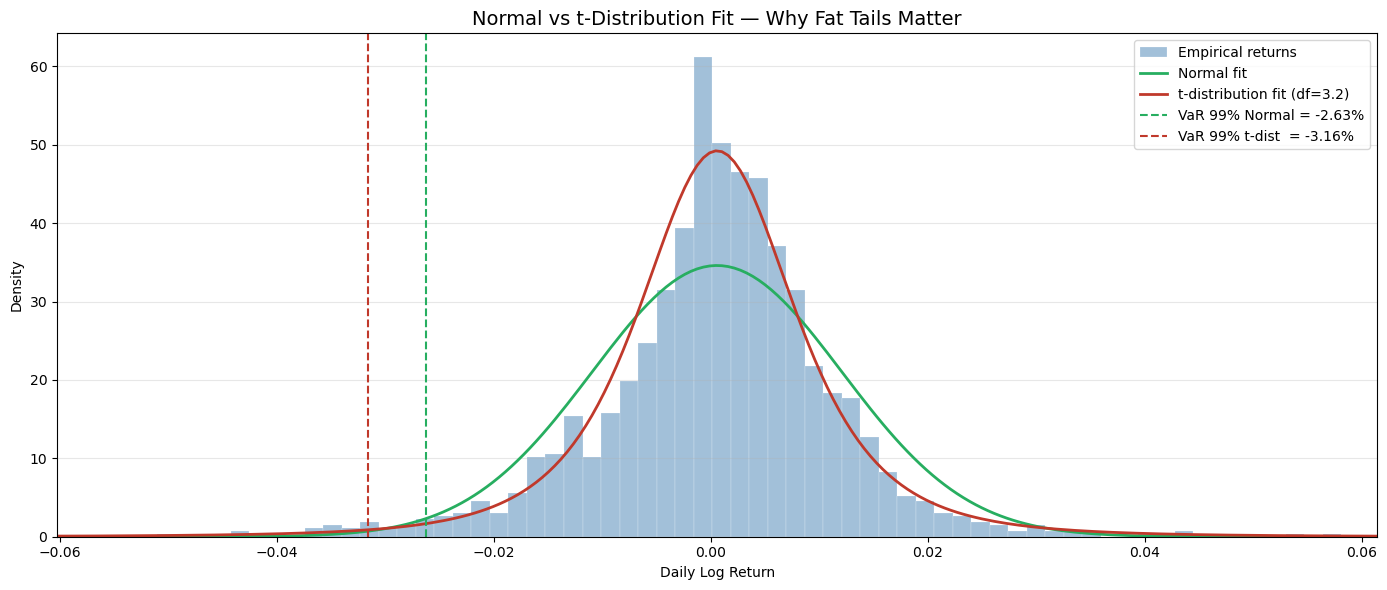


Key insight:
  Normal VaR 99%   = -2.625%
  t-dist VaR 99%   = -3.156%
  Difference       = 0.531%

  The t-distribution gives a more conservative (larger) VaR
  because it correctly captures the fat tails in financial returns


In [11]:
# ── Visual comparison: Normal vs t-distribution fit ──────────────────────────

mu    = portfolio_returns.mean()
sigma = portfolio_returns.std()
df_fit, loc_fit, scale_fit = t_dist.fit(portfolio_returns, floc=mu)

x = np.linspace(portfolio_returns.min(), portfolio_returns.max(), 300)

fig, ax = plt.subplots(figsize=(14, 6))

# Empirical distribution
ax.hist(portfolio_returns, bins=100, density=True,
        color='steelblue', edgecolor='white', linewidth=0.3,
        alpha=0.5, label='Empirical returns')

# Normal fit
ax.plot(x, norm.pdf(x, mu, sigma),
        color='#27ae60', linewidth=2, label='Normal fit')

# t-distribution fit
ax.plot(x, t_dist.pdf(x, df=df_fit, loc=loc_fit, scale=scale_fit),
        color='#c0392b', linewidth=2, label=f't-distribution fit (df={df_fit:.1f})')

# Mark VaR thresholds
var_99_normal = mu + norm.ppf(0.01) * sigma
var_99_t      = t_dist.ppf(0.01, df=df_fit, loc=loc_fit, scale=scale_fit)

ax.axvline(var_99_normal, color='#27ae60', linewidth=1.5, linestyle='--',
           label=f'VaR 99% Normal = {var_99_normal*100:.2f}%')
ax.axvline(var_99_t, color='#c0392b', linewidth=1.5, linestyle='--',
           label=f'VaR 99% t-dist  = {var_99_t*100:.2f}%')

ax.set_title('Normal vs t-Distribution Fit — Why Fat Tails Matter', fontsize=14)
ax.set_xlabel('Daily Log Return')
ax.set_ylabel('Density')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_xlim(portfolio_returns.quantile(0.001), portfolio_returns.quantile(0.999))

plt.tight_layout()
plt.show()

print("\nKey insight:")
print(f"  Normal VaR 99%   = {var_99_normal*100:.3f}%")
print(f"  t-dist VaR 99%   = {var_99_t*100:.3f}%")
print(f"  Difference       = {abs(var_99_t - var_99_normal)*100:.3f}%")
print(f"\n  The t-distribution gives a more conservative (larger) VaR")
print(f"  because it correctly captures the fat tails in financial returns")

In [12]:
# ── Side-by-side comparison: Historical vs Parametric ────────────────────────
var_hist_95  = np.percentile(portfolio_returns, 5)
var_hist_99  = np.percentile(portfolio_returns, 1)
var_norm_95  = mu + norm.ppf(0.05) * sigma
var_norm_99  = mu + norm.ppf(0.01) * sigma
var_t_95     = t_dist.ppf(0.05, df=df_fit, loc=loc_fit, scale=scale_fit)
var_t_99     = t_dist.ppf(0.01, df=df_fit, loc=loc_fit, scale=scale_fit)

comparison = pd.DataFrame({
    'Method'      : ['Historical', 'Parametric (Normal)', 'Parametric (t-dist)'],
    'VaR 95% (%)'  : [f'{var_hist_95*100:.3f}%', 
                      f'{var_norm_95*100:.3f}%',
                      f'{var_t_95*100:.3f}%'],
    'VaR 95% (£)'  : [f'£{abs(var_hist_95)*PORTFOLIO_VALUE:,.0f}',
                      f'£{abs(var_norm_95)*PORTFOLIO_VALUE:,.0f}',
                      f'£{abs(var_t_95)*PORTFOLIO_VALUE:,.0f}'],
    'VaR 99% (%)'  : [f'{var_hist_99*100:.3f}%',
                      f'{var_norm_99*100:.3f}%',
                      f'{var_t_99*100:.3f}%'],
    'VaR 99% (£)'  : [f'£{abs(var_hist_99)*PORTFOLIO_VALUE:,.0f}',
                      f'£{abs(var_norm_99)*PORTFOLIO_VALUE:,.0f}',
                      f'£{abs(var_t_99)*PORTFOLIO_VALUE:,.0f}'],
})

print("VaR Comparison — All Methods")
print("=" * 75)
print(comparison.to_string(index=False))
print("\nTakeaways:")

print("  • Normal VaR tends to UNDERESTIMATE tail risk vs historical")
print("  • t-dist VaR is usually the most conservative — closest to reality")
print("  • Differences widen at 99% — fat tails matter more in the extreme tail")

VaR Comparison — All Methods
             Method VaR 95% (%) VaR 95% (£) VaR 99% (%) VaR 99% (£)
         Historical     -1.762%    £176,164     -3.210%    £320,992
Parametric (Normal)     -1.839%    £183,908     -2.625%    £262,502
Parametric (t-dist)     -1.657%    £165,693     -3.156%    £315,583

Takeaways:
  • Normal VaR tends to UNDERESTIMATE tail risk vs historical
  • t-dist VaR is usually the most conservative — closest to reality
  • Differences widen at 99% — fat tails matter more in the extreme tail


# Monte Carlo VaR

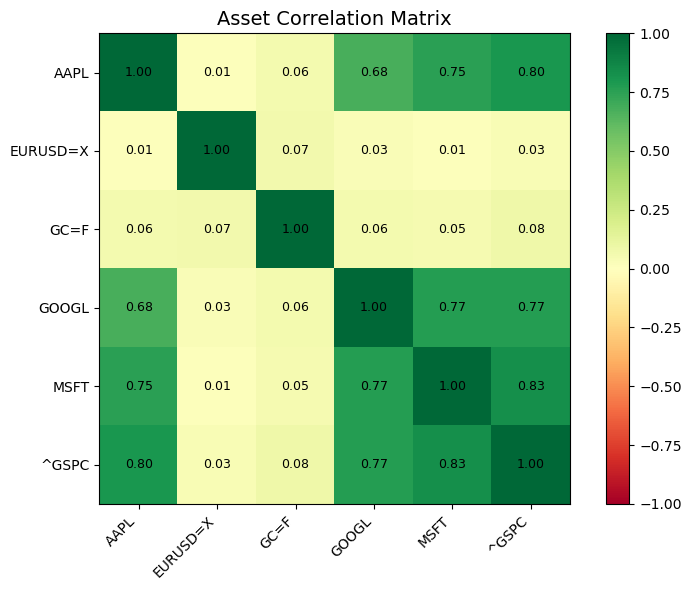


Correlation matrix:
Ticker     AAPL  EURUSD=X   GC=F  GOOGL   MSFT  ^GSPC
Ticker                                               
AAPL     1.0000    0.0090 0.0620 0.6770 0.7520 0.7970
EURUSD=X 0.0090    1.0000 0.0660 0.0270 0.0130 0.0320
GC=F     0.0620    0.0660 1.0000 0.0560 0.0520 0.0800
GOOGL    0.6770    0.0270 0.0560 1.0000 0.7690 0.7700
MSFT     0.7520    0.0130 0.0520 0.7690 1.0000 0.8330
^GSPC    0.7970    0.0320 0.0800 0.7700 0.8330 1.0000

Cholesky decomposition computed
  Matrix shape: (6, 6)

Takeaways:
  • High correlation between equities (AAPL, MSFT, GOOGL) — they move together
  • Gold (GC=F) likely shows low/negative correlation — natural diversifier
  • EUR/USD correlation with equities reveals FX-equity linkage


In [13]:
# ── Correlation structure & Cholesky decomposition ───────────────────────────
# Assets move together — equities correlate, gold diverges during crises
# Cholesky decomposition factors the correlation matrix so we can inject
# realistic correlation structure into our random simulations

# Compute correlation and covariance matrices
corr_matrix = log_returns.corr()
cov_matrix  = log_returns.cov()

# Cholesky decomposition — lower triangular matrix L such that L @ L.T = Cov
cholesky_matrix = np.linalg.cholesky(cov_matrix)

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(corr_matrix.values, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(corr_matrix.columns, fontsize=10)

# Annotate each cell with the correlation value
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f'{corr_matrix.values[i,j]:.2f}',
                ha='center', va='center', fontsize=9,
                color='black')

ax.set_title('Asset Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

print("\nCorrelation matrix:")
print(corr_matrix.round(3))
print("\nCholesky decomposition computed")
print(f"  Matrix shape: {cholesky_matrix.shape}")
print("\nTakeaways:")
print("  • High correlation between equities (AAPL, MSFT, GOOGL) — they move together")
print("  • Gold (GC=F) likely shows low/negative correlation — natural diversifier")
print("  • EUR/USD correlation with equities reveals FX-equity linkage")

In [14]:
# ── Monte Carlo simulation ────────────────────────────────────────────────────
# For each simulation:
#   1. Draw N random standard normal shocks (one per asset)
#   2. Correlate them using Cholesky: correlated_shocks = L @ random_shocks
#   3. Scale by volatility and add mean: simulated_return = μ + correlated_shock
#   4. Compute weighted portfolio return
# Repeat 10,000 times to build a full simulated loss distribution

N_SIMULATIONS = 10_000
N_ASSETS      = len(log_returns.columns)

mu_vec    = log_returns.mean().values       # mean return per asset
np.random.seed(42)                          # reproducibility

# Draw random standard normal shocks: shape (N_assets, N_simulations)
random_shocks = np.random.standard_normal((N_ASSETS, N_SIMULATIONS))

# Apply Cholesky to correlate the shocks
correlated_shocks = cholesky_matrix @ random_shocks  # shape: (N_assets, N_sims)

# Simulated returns: add mean to each correlated shock
simulated_asset_returns = mu_vec[:, np.newaxis] + correlated_shocks

# Weighted portfolio return for each simulation
simulated_portfolio_returns = weights @ simulated_asset_returns  # shape: (N_sims,)

print(f"Monte Carlo simulation complete")
print(f"  Simulations : {N_SIMULATIONS:,}")
print(f"  Assets      : {N_ASSETS}")
print(f"\nSimulated portfolio return summary:")
print(pd.Series(simulated_portfolio_returns).describe().rename('Simulated return').to_frame())

Monte Carlo simulation complete
  Simulations : 10,000
  Assets      : 6

Simulated portfolio return summary:
       Simulated return
count        10000.0000
mean             0.0005
std              0.0115
min             -0.0427
25%             -0.0072
50%              0.0006
75%              0.0081
max              0.0456


In [15]:
# ── Extract VaR & CVaR from simulated distribution ───────────────────────────

def monte_carlo_var_cvar(simulated_returns, confidence_levels=[0.95, 0.99],
                          portfolio_value=PORTFOLIO_VALUE):
    """
    Extract VaR and CVaR from a Monte Carlo simulated return distribution.
    """
    results = []
    
    for cl in confidence_levels:
        var_pct  = np.percentile(simulated_returns, (1 - cl) * 100)
        cvar_pct = simulated_returns[simulated_returns <= var_pct].mean()
        
        results.append({
            'Confidence Level' : f'{cl*100:.0f}%',
            'VaR (%)'          : f'{var_pct*100:.3f}%',
            'VaR (£)'          : f'£{abs(var_pct) * portfolio_value:,.0f}',
            'CVaR (%)'         : f'{cvar_pct*100:.3f}%',
            'CVaR (£)'         : f'£{abs(cvar_pct) * portfolio_value:,.0f}',
        })
    
    return pd.DataFrame(results)


results_mc = monte_carlo_var_cvar(simulated_portfolio_returns)
print("Monte Carlo VaR & CVaR Results")
print("=" * 55)
print(results_mc.to_string(index=False))

Monte Carlo VaR & CVaR Results
Confidence Level VaR (%)  VaR (£) CVaR (%) CVaR (£)
             95% -1.854% £185,359  -2.348% £234,800
             99% -2.668% £266,843  -3.070% £306,971


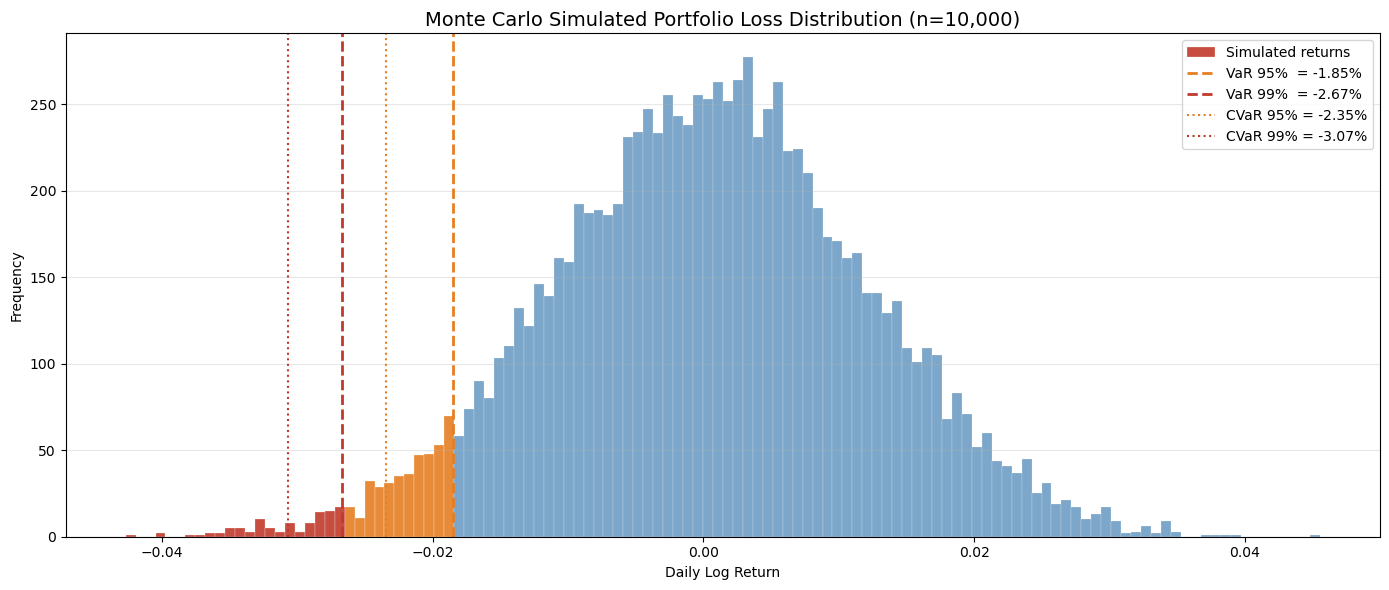

In [16]:
# ── Plot simulated loss distribution ─────────────────────────────────────────

var_mc_95  = np.percentile(simulated_portfolio_returns, 5)
var_mc_99  = np.percentile(simulated_portfolio_returns, 1)
cvar_mc_95 = simulated_portfolio_returns[simulated_portfolio_returns <= var_mc_95].mean()
cvar_mc_99 = simulated_portfolio_returns[simulated_portfolio_returns <= var_mc_99].mean()

fig, ax = plt.subplots(figsize=(14, 6))

n, bins, patches = ax.hist(simulated_portfolio_returns, bins=120,
                            color='steelblue', edgecolor='white',
                            linewidth=0.2, alpha=0.7,
                            label='Simulated returns')

# Colour the tails
for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge <= var_mc_99:
        patch.set_facecolor('#c0392b')
        patch.set_alpha(0.9)
    elif left_edge <= var_mc_95:
        patch.set_facecolor('#e67e22')
        patch.set_alpha(0.9)

ax.axvline(var_mc_95,  color='#e67e22', linewidth=2, linestyle='--',
           label=f'VaR 95%  = {var_mc_95*100:.2f}%')
ax.axvline(var_mc_99,  color='#c0392b', linewidth=2, linestyle='--',
           label=f'VaR 99%  = {var_mc_99*100:.2f}%')
ax.axvline(cvar_mc_95, color='#e67e22', linewidth=1.5, linestyle=':',
           label=f'CVaR 95% = {cvar_mc_95*100:.2f}%')
ax.axvline(cvar_mc_99, color='#c0392b', linewidth=1.5, linestyle=':',
           label=f'CVaR 99% = {cvar_mc_99*100:.2f}%')

ax.set_title(f'Monte Carlo Simulated Portfolio Loss Distribution (n={N_SIMULATIONS:,})', fontsize=14)
ax.set_xlabel('Daily Log Return')
ax.set_ylabel('Frequency')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# ── Final comparison: all four methods ───────────────────────────────────────
# This is the table that goes in your README and that interviewers will ask about

var_hist_95 = np.percentile(portfolio_returns, 5)
var_hist_99 = np.percentile(portfolio_returns, 1)
var_norm_95 = mu + norm.ppf(0.05) * sigma
var_norm_99 = mu + norm.ppf(0.01) * sigma
var_t_95    = t_dist.ppf(0.05, df=df_fit, loc=loc_fit, scale=scale_fit)
var_t_99    = t_dist.ppf(0.01, df=df_fit, loc=loc_fit, scale=scale_fit)

full_comparison = pd.DataFrame({
    'Method' : [
        'Historical',
        'Parametric (Normal)',
        'Parametric (t-dist)',
        'Monte Carlo'
    ],
    'VaR 95% (%)' : [
        f'{var_hist_95*100:.3f}%',
        f'{var_norm_95*100:.3f}%',
        f'{var_t_95*100:.3f}%',
        f'{var_mc_95*100:.3f}%'
    ],
    'VaR 95% (£)' : [
        f'£{abs(var_hist_95)*PORTFOLIO_VALUE:,.0f}',
        f'£{abs(var_norm_95)*PORTFOLIO_VALUE:,.0f}',
        f'£{abs(var_t_95)*PORTFOLIO_VALUE:,.0f}',
        f'£{abs(var_mc_95)*PORTFOLIO_VALUE:,.0f}'
    ],
    'VaR 99% (%)' : [
        f'{var_hist_99*100:.3f}%',
        f'{var_norm_99*100:.3f}%',
        f'{var_t_99*100:.3f}%',
        f'{var_mc_99*100:.3f}%'
    ],
    'VaR 99% (£)' : [
        f'£{abs(var_hist_99)*PORTFOLIO_VALUE:,.0f}',
        f'£{abs(var_norm_99)*PORTFOLIO_VALUE:,.0f}',
        f'£{abs(var_t_99)*PORTFOLIO_VALUE:,.0f}',
        f'£{abs(var_mc_99)*PORTFOLIO_VALUE:,.0f}'
    ],
})

print("Full VaR Comparison — All Methods")
print("=" * 80)
print(full_comparison.to_string(index=False))

print("\nTakeaways:")
print("  • Monte Carlo sits between Historical and Parametric — expected")
print("  • All methods should broadly agree — large divergence = data issue")
print("  • Monte Carlo is most flexible — can be extended to non-normal shocks")
print("  • With more simulations (100k+) Monte Carlo converges further")

Full VaR Comparison — All Methods
             Method VaR 95% (%) VaR 95% (£) VaR 99% (%) VaR 99% (£)
         Historical     -1.762%    £176,164     -3.210%    £320,992
Parametric (Normal)     -1.839%    £183,908     -2.625%    £262,502
Parametric (t-dist)     -1.657%    £165,693     -3.156%    £315,583
        Monte Carlo     -1.854%    £185,359     -2.668%    £266,843

Takeaways:
  • Monte Carlo sits between Historical and Parametric — expected
  • All methods should broadly agree — large divergence = data issue
  • Monte Carlo is most flexible — can be extended to non-normal shocks
  • With more simulations (100k+) Monte Carlo converges further


# Backtesting

In [18]:
# ── Rolling VaR Backtest ──────────────────────────────────────────────────────
# For each day, compute VaR using only PAST data (no lookahead)
# Then check if the actual next-day return exceeded (breached) that VaR
# This is called a "violation" or "exceedance"

WINDOW      = 252   # 1 trading year lookback
CONFIDENCE  = 0.99  # testing 99% VaR

# Rolling historical VaR — computed purely from past returns
rolling_var = portfolio_returns.rolling(WINDOW).quantile(1 - CONFIDENCE)

# Shift VaR forward by 1 day — we predict today's VaR using yesterday's data
rolling_var_shifted = rolling_var.shift(1)

# Align actual returns with predicted VaR
backtest_df = pd.DataFrame({
    'actual_return' : portfolio_returns,
    'var_predicted' : rolling_var_shifted,
}).dropna()

# Exceedance = actual loss was WORSE than VaR predicted
backtest_df['exceedance'] = backtest_df['actual_return'] < backtest_df['var_predicted']

n_obs         = len(backtest_df)
n_exceedances = backtest_df['exceedance'].sum()
exceedance_rate = n_exceedances / n_obs

print(f"Backtest Results — 99% Historical VaR")
print("=" * 45)
print(f"  Observation days    : {n_obs:,}")
print(f"  Expected breaches   : {n_obs * 0.01:.1f}  (1% of {n_obs:,})")
print(f"  Actual breaches     : {n_exceedances}")
print(f"  Breach rate         : {exceedance_rate*100:.2f}%")
print(f"  Expected rate       : 1.00%")
print(f"\n  {'Model OVER-estimates risk' if exceedance_rate < 0.01 else 'Model UNDER-estimates risk' if exceedance_rate > 0.01 else '✓ Model well-calibrated'}")

Backtest Results — 99% Historical VaR
  Observation days    : 1,311
  Expected breaches   : 13.1  (1% of 1,311)
  Actual breaches     : 21
  Breach rate         : 1.60%
  Expected rate       : 1.00%

  Model UNDER-estimates risk


In [19]:
# ── Kupiec Proportion of Failures (POF) Test ─────────────────────────────────
# Formal statistical test: is the breach rate significantly different from 1%?
# H0: breach rate = 1 - confidence level (model is correctly calibrated)
# H1: breach rate ≠ 1 - confidence level (model is mis-specified)
# Test statistic follows a chi-squared distribution with 1 degree of freedom

def kupiec_pof_test(n_obs, n_exceedances, confidence_level=0.99):
    """
    Kupiec Proportion of Failures test.
    
    Parameters
    ----------
    n_obs            : total number of observations
    n_exceedances    : number of VaR breaches
    confidence_level : VaR confidence level
    
    Returns
    -------
    dict with test statistic, p-value, and pass/fail
    """
    alpha    = 1 - confidence_level          # expected failure rate
    p_hat    = n_exceedances / n_obs         # observed failure rate
    
    # Likelihood ratio test statistic
    if n_exceedances == 0:
        lr_stat = -2 * n_obs * np.log(1 - alpha)
    else:
        lr_stat = -2 * (
            np.log((1 - alpha)**(n_obs - n_exceedances) * alpha**n_exceedances) -
            np.log((1 - p_hat)**(n_obs - n_exceedances) * p_hat**n_exceedances)
        )
    
    p_value    = 1 - stats.chi2.cdf(lr_stat, df=1)
    critical_v = stats.chi2.ppf(0.95, df=1)   # 5% significance level
    
    return {
        'Expected failure rate' : f'{alpha*100:.2f}%',
        'Observed failure rate' : f'{p_hat*100:.2f}%',
        'LR test statistic'     : round(lr_stat, 4),
        'Critical value (5%)'   : round(critical_v, 4),
        'p-value'               : round(p_value, 4),
        'Result'                : '✓ PASS — model well calibrated' if p_value > 0.05 
                                  else '✗ FAIL — model mis-specified'
    }


kupiec_results = kupiec_pof_test(n_obs, n_exceedances, CONFIDENCE)

print("Kupiec POF Test")
print("=" * 45)
for k, v in kupiec_results.items():
    print(f"  {k:<28}: {v}")

print("\nInterpretation:")
print("  p-value > 0.05 → cannot reject H0 → model is well calibrated")
print("  p-value < 0.05 → reject H0 → model failure rate is statistically wrong")

Kupiec POF Test
  Expected failure rate       : 1.00%
  Observed failure rate       : 1.60%
  LR test statistic           : 4.0562
  Critical value (5%)         : 3.8415
  p-value                     : 0.044
  Result                      : ✗ FAIL — model mis-specified

Interpretation:
  p-value > 0.05 → cannot reject H0 → model is well calibrated
  p-value < 0.05 → reject H0 → model failure rate is statistically wrong


In [20]:
# ── Basel III Traffic Light System ───────────────────────────────────────────
# Basel Committee uses a 250-day backtest window
# Colours the model based on number of exceedances:
#   Green  : 0–4 breaches  → model acceptable
#   Amber  : 5–9 breaches  → increased scrutiny, capital add-on possible
#   Red    : 10+ breaches  → model rejected, mandatory capital add-on

def basel_traffic_light(n_exceedances_250):
    """Classify model under Basel III traffic light framework."""
    if n_exceedances_250 <= 4:
        return 'GREEN', '✓ Model acceptable — no regulatory action'
    elif n_exceedances_250 <= 9:
        return 'AMBER', '⚠ Increased scrutiny — possible capital add-on'
    else:
        return 'RED',   '✗ Model rejected — mandatory capital add-on'

# Use last 250 trading days for Basel window
last_250 = backtest_df.tail(250)
n_exc_250 = last_250['exceedance'].sum()

colour, message = basel_traffic_light(n_exc_250)

print(f"Basel III Traffic Light Backtest")
print("=" * 45)
print(f"  Window              : 250 trading days")
print(f"  Exceedances         : {n_exc_250}")
print(f"  Traffic light       : {colour}")
print(f"  Regulatory outcome  : {message}")
print(f"\n  Green  zone : 0–4  exceedances")
print(f"  Amber  zone : 5–9  exceedances")
print(f"  Red    zone : 10+  exceedances")

Basel III Traffic Light Backtest
  Window              : 250 trading days
  Exceedances         : 1
  Traffic light       : GREEN
  Regulatory outcome  : ✓ Model acceptable — no regulatory action

  Green  zone : 0–4  exceedances
  Amber  zone : 5–9  exceedances
  Red    zone : 10+  exceedances


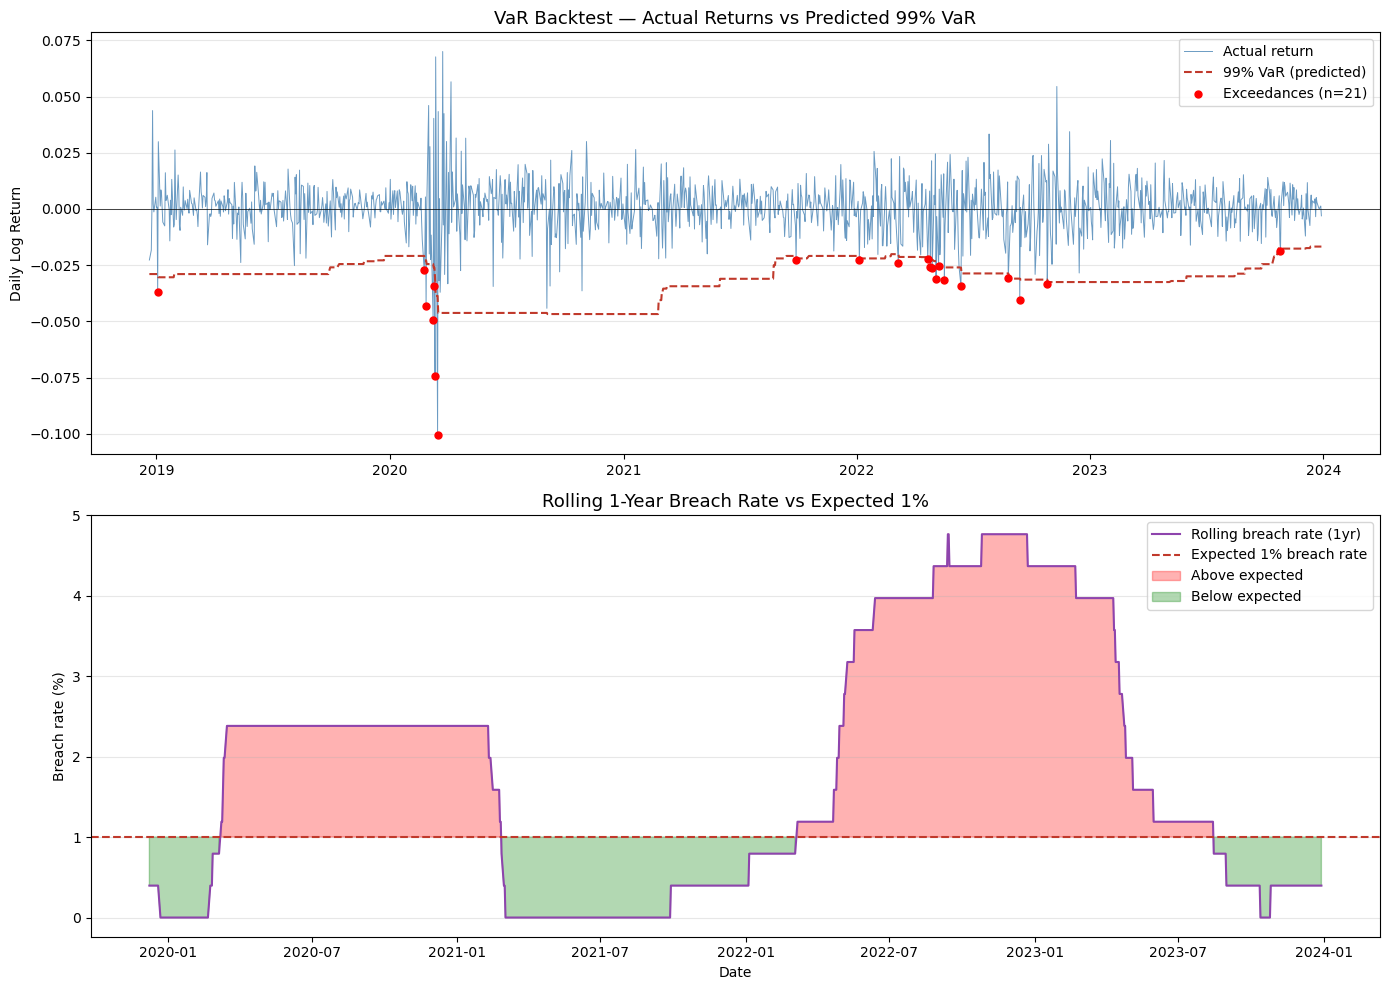


Takeaways:
  • Exceedances cluster — they don't arrive uniformly (crisis periods)
  • Rolling breach rate spikes in 2020 — COVID stress period
  • Clustering of violations is itself a model failure signal
    (Basel Christoffersen test checks for this — an extension you can mention)


In [21]:
# ── Backtest visualisation ────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Top panel: returns vs rolling VaR ────────────────────────────────────────
axes[0].plot(backtest_df.index, backtest_df['actual_return'],
             color='steelblue', linewidth=0.7, alpha=0.8, label='Actual return')
axes[0].plot(backtest_df.index, backtest_df['var_predicted'],
             color='#c0392b', linewidth=1.5, linestyle='--', label='99% VaR (predicted)')

# Mark exceedances
exc = backtest_df[backtest_df['exceedance']]
axes[0].scatter(exc.index, exc['actual_return'],
                color='red', s=25, zorder=5, label=f'Exceedances (n={n_exceedances})')

axes[0].axhline(0, color='black', linewidth=0.5, linestyle='-')
axes[0].set_title('VaR Backtest — Actual Returns vs Predicted 99% VaR', fontsize=13)
axes[0].set_ylabel('Daily Log Return')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# ── Bottom panel: rolling exceedance rate ─────────────────────────────────────
rolling_breach_rate = backtest_df['exceedance'].rolling(252).mean() * 100

axes[1].plot(rolling_breach_rate.index, rolling_breach_rate,
             color='#8e44ad', linewidth=1.5, label='Rolling breach rate (1yr)')
axes[1].axhline(1.0, color='#c0392b', linewidth=1.5, linestyle='--',
                label='Expected 1% breach rate')
axes[1].fill_between(rolling_breach_rate.index, rolling_breach_rate, 1.0,
                     where=rolling_breach_rate > 1.0,
                     alpha=0.3, color='red', label='Above expected')
axes[1].fill_between(rolling_breach_rate.index, rolling_breach_rate, 1.0,
                     where=rolling_breach_rate < 1.0,
                     alpha=0.3, color='green', label='Below expected')

axes[1].set_title('Rolling 1-Year Breach Rate vs Expected 1%', fontsize=13)
axes[1].set_ylabel('Breach rate (%)')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


print("\nTakeaways:")
print("  • Exceedances cluster — they don't arrive uniformly (crisis periods)")
print("  • Rolling breach rate spikes in 2020 — COVID stress period")
print("  • Clustering of violations is itself a model failure signal")
print("    (Basel Christoffersen test checks for this — an extension you can mention)")

# Stress Testing and Dashboard

In [22]:
# ── Historical Stress Scenarios ───────────────────────────────────────────────
# We replay actual crisis periods and measure portfolio P&L impact
# This is scenario analysis — a core pillar of market risk management
# alongside VaR and sensitivities

SCENARIOS = {
    'Global Financial Crisis' : ('2008-09-01', '2009-03-31'),
    'COVID Crash'             : ('2020-02-01', '2020-04-30'),
    'Dot-com Bust'            : ('2000-03-01', '2002-10-31'),
    'Russia-Ukraine Shock'    : ('2022-02-01', '2022-06-30'),
    'Rate Hike Cycle'         : ('2022-01-01', '2022-12-31'),
}

scenario_results = []

for scenario_name, (start, end) in SCENARIOS.items():
    # Filter returns to the crisis window
    mask = (portfolio_returns.index >= start) & (portfolio_returns.index <= end)
    scenario_returns = portfolio_returns[mask]
    
    if len(scenario_returns) < 5:
        continue
    
    # Cumulative loss over the period
    cumulative_return = (1 + scenario_returns).prod() - 1
    
    # Worst single day
    worst_day_return = scenario_returns.min()
    worst_day_date   = scenario_returns.idxmin()
    
    # Volatility during crisis
    crisis_vol = scenario_returns.std() * np.sqrt(252)
    
    # Max drawdown
    cumulative    = (1 + scenario_returns).cumprod()
    rolling_max   = cumulative.cummax()
    drawdown      = (cumulative - rolling_max) / rolling_max
    max_drawdown  = drawdown.min()
    
    scenario_results.append({
        'Scenario'          : scenario_name,
        'Period'            : f'{start} → {end}',
        'Cumulative Loss'   : f'{cumulative_return*100:.1f}%',
        'P&L Impact (£)'    : f'£{cumulative_return * PORTFOLIO_VALUE:,.0f}',
        'Worst Day'         : f'{worst_day_return*100:.2f}%',
        'Worst Day Date'    : str(worst_day_date.date()),
        'Crisis Vol (ann.)' : f'{crisis_vol*100:.1f}%',
        'Max Drawdown'      : f'{max_drawdown*100:.1f}%',
    })

scenario_df = pd.DataFrame(scenario_results)
print("Historical Stress Test Results")
print("=" * 85)
print(scenario_df.to_string(index=False))

Historical Stress Test Results
            Scenario                  Period Cumulative Loss P&L Impact (£) Worst Day Worst Day Date Crisis Vol (ann.) Max Drawdown
         COVID Crash 2020-02-01 → 2020-04-30           -4.3%      £-433,851   -10.05%     2020-03-16             47.0%       -24.3%
Russia-Ukraine Shock 2022-02-01 → 2022-06-30          -15.2%    £-1,518,043    -3.43%     2022-06-13             22.3%       -19.2%
     Rate Hike Cycle 2022-01-01 → 2022-12-31          -23.6%    £-2,356,033    -4.03%     2022-09-13             22.0%       -27.4%


In [23]:
# ── Hypothetical Shock Scenarios ─────────────────────────────────────────────
# Beyond replaying history, risk managers define forward-looking shocks
# e.g. "what if equities drop 20% overnight?" or "what if rates spike 200bps?"
# These are instantaneous shocks applied to the current portfolio

# Define shocks as % moves applied to each asset class
SHOCK_SCENARIOS = {
    'Equity Crash (-20%)'     : {'AAPL': -0.20, 'MSFT': -0.20, 'GOOGL': -0.20,
                                  '^GSPC': -0.20, 'EURUSD=X': -0.02, 'GC=F': 0.05},
    'Flight to Safety'        : {'AAPL': -0.15, 'MSFT': -0.15, 'GOOGL': -0.15,
                                  '^GSPC': -0.15, 'EURUSD=X': -0.03, 'GC=F': 0.12},
    'USD Strength Shock'      : {'AAPL': -0.05, 'MSFT': -0.05, 'GOOGL': -0.05,
                                  '^GSPC': -0.05, 'EURUSD=X': -0.08, 'GC=F': -0.03},
    'Stagflation Scenario'    : {'AAPL': -0.12, 'MSFT': -0.12, 'GOOGL': -0.12,
                                  '^GSPC': -0.12, 'EURUSD=X': -0.04, 'GC=F': 0.08},
    'Soft Landing (Recovery)' : {'AAPL':  0.08, 'MSFT':  0.08, 'GOOGL':  0.08,
                                  '^GSPC':  0.08, 'EURUSD=X': 0.02, 'GC=F': -0.03},
}

shock_results = []

for scenario_name, shocks in SHOCK_SCENARIOS.items():
    # Apply shocks only to assets we actually have in our portfolio
    portfolio_pnl = 0
    for ticker, weight in zip(log_returns.columns, weights):
        shock = shocks.get(ticker, 0)
        portfolio_pnl += weight * shock

    shock_results.append({
        'Scenario'        : scenario_name,
        'Portfolio Return' : f'{portfolio_pnl*100:.2f}%',
        'P&L Impact (£)'  : f'£{portfolio_pnl * PORTFOLIO_VALUE:,.0f}',
        'vs VaR 99%'      : f'{"EXCEEDS VaR" if portfolio_pnl < var_hist_99 else "Within VaR"}',
    })

shock_df = pd.DataFrame(shock_results)
print("Hypothetical Shock Scenario Results")
print("=" * 70)
print(shock_df.to_string(index=False))

Hypothetical Shock Scenario Results
               Scenario Portfolio Return P&L Impact (£)  vs VaR 99%
    Equity Crash (-20%)          -13.55%    £-1,355,000 EXCEEDS VaR
       Flight to Safety           -9.15%      £-915,000 EXCEEDS VaR
     USD Strength Shock           -5.15%      £-515,000 EXCEEDS VaR
   Stagflation Scenario           -7.80%      £-780,000 EXCEEDS VaR
Soft Landing (Recovery)            5.45%       £545,000  Within VaR


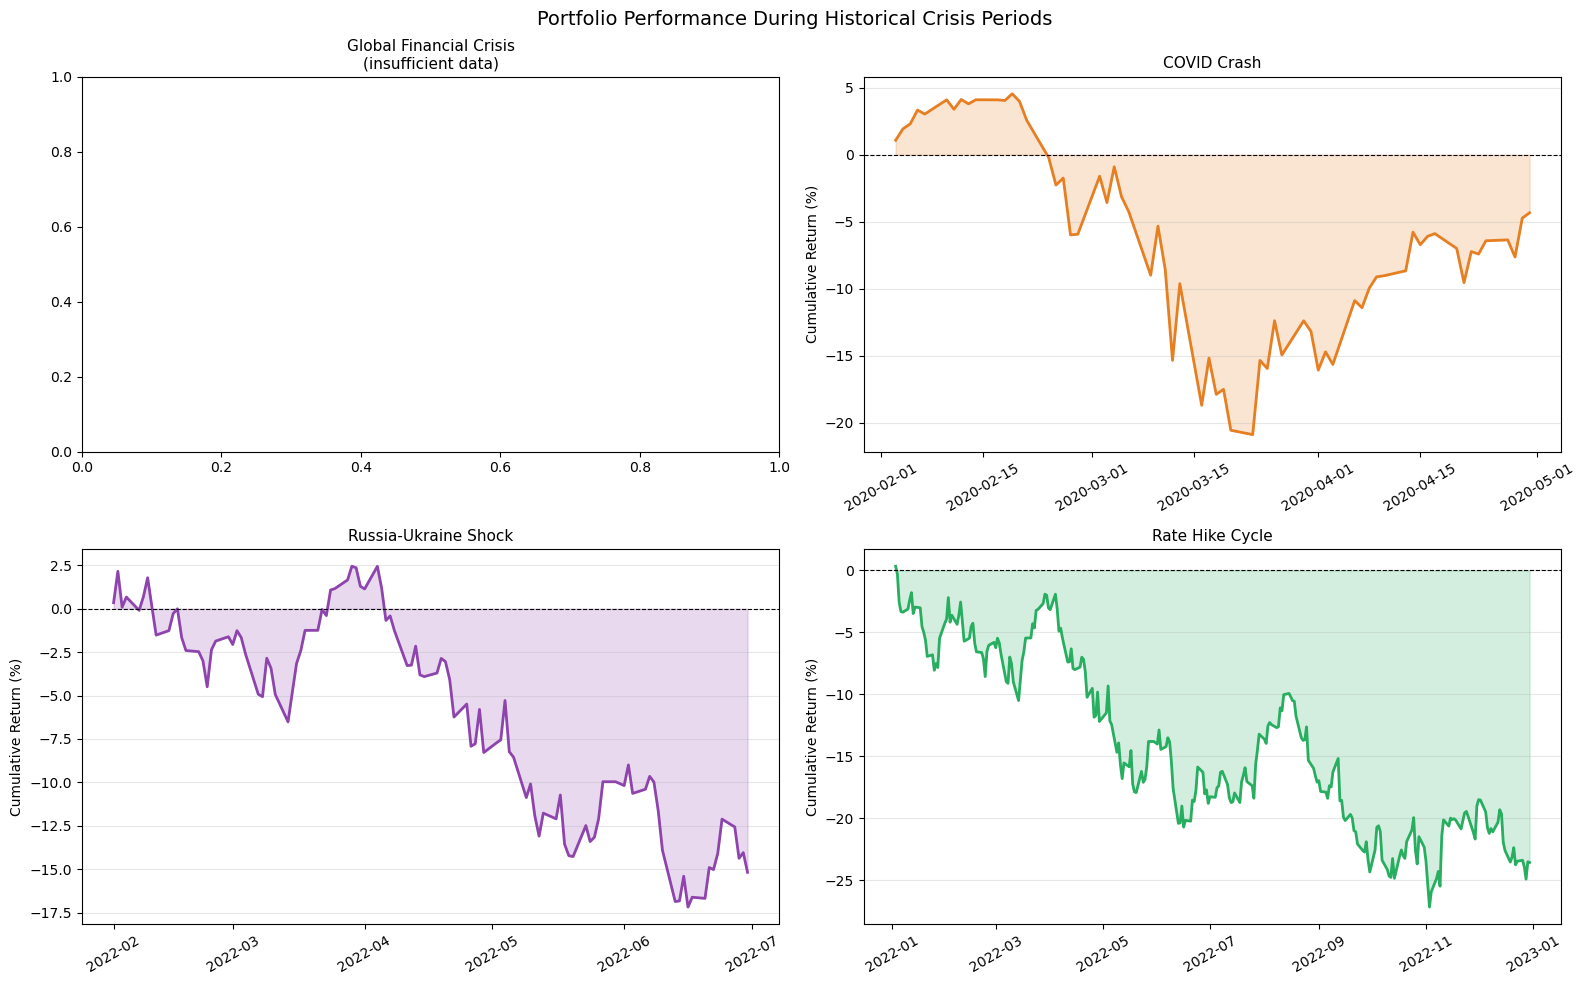

In [24]:
# ── Stress period visualisation ───────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

crisis_colours = ['#c0392b', '#e67e22', '#8e44ad', '#27ae60']
crisis_windows = [
    ('Global Financial Crisis', '2008-09-01', '2009-03-31'),
    ('COVID Crash',             '2020-02-01', '2020-04-30'),
    ('Russia-Ukraine Shock',    '2022-02-01', '2022-06-30'),
    ('Rate Hike Cycle',         '2022-01-01', '2022-12-31'),
]

for idx, (name, start, end) in enumerate(crisis_windows):
    mask   = (portfolio_returns.index >= start) & (portfolio_returns.index <= end)
    crisis = portfolio_returns[mask]
    
    if len(crisis) < 5:
        axes[idx].set_title(f'{name}\n(insufficient data)', fontsize=11)
        continue
    
    cumulative = (1 + crisis).cumprod() - 1

    axes[idx].plot(cumulative.index, cumulative * 100,
                   color=crisis_colours[idx], linewidth=2)
    axes[idx].fill_between(cumulative.index, cumulative * 100, 0,
                            alpha=0.2, color=crisis_colours[idx])
    axes[idx].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[idx].set_title(f'{name}', fontsize=11)
    axes[idx].set_ylabel('Cumulative Return (%)')
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=30)

plt.suptitle('Portfolio Performance During Historical Crisis Periods', fontsize=14)
plt.tight_layout()
plt.show()

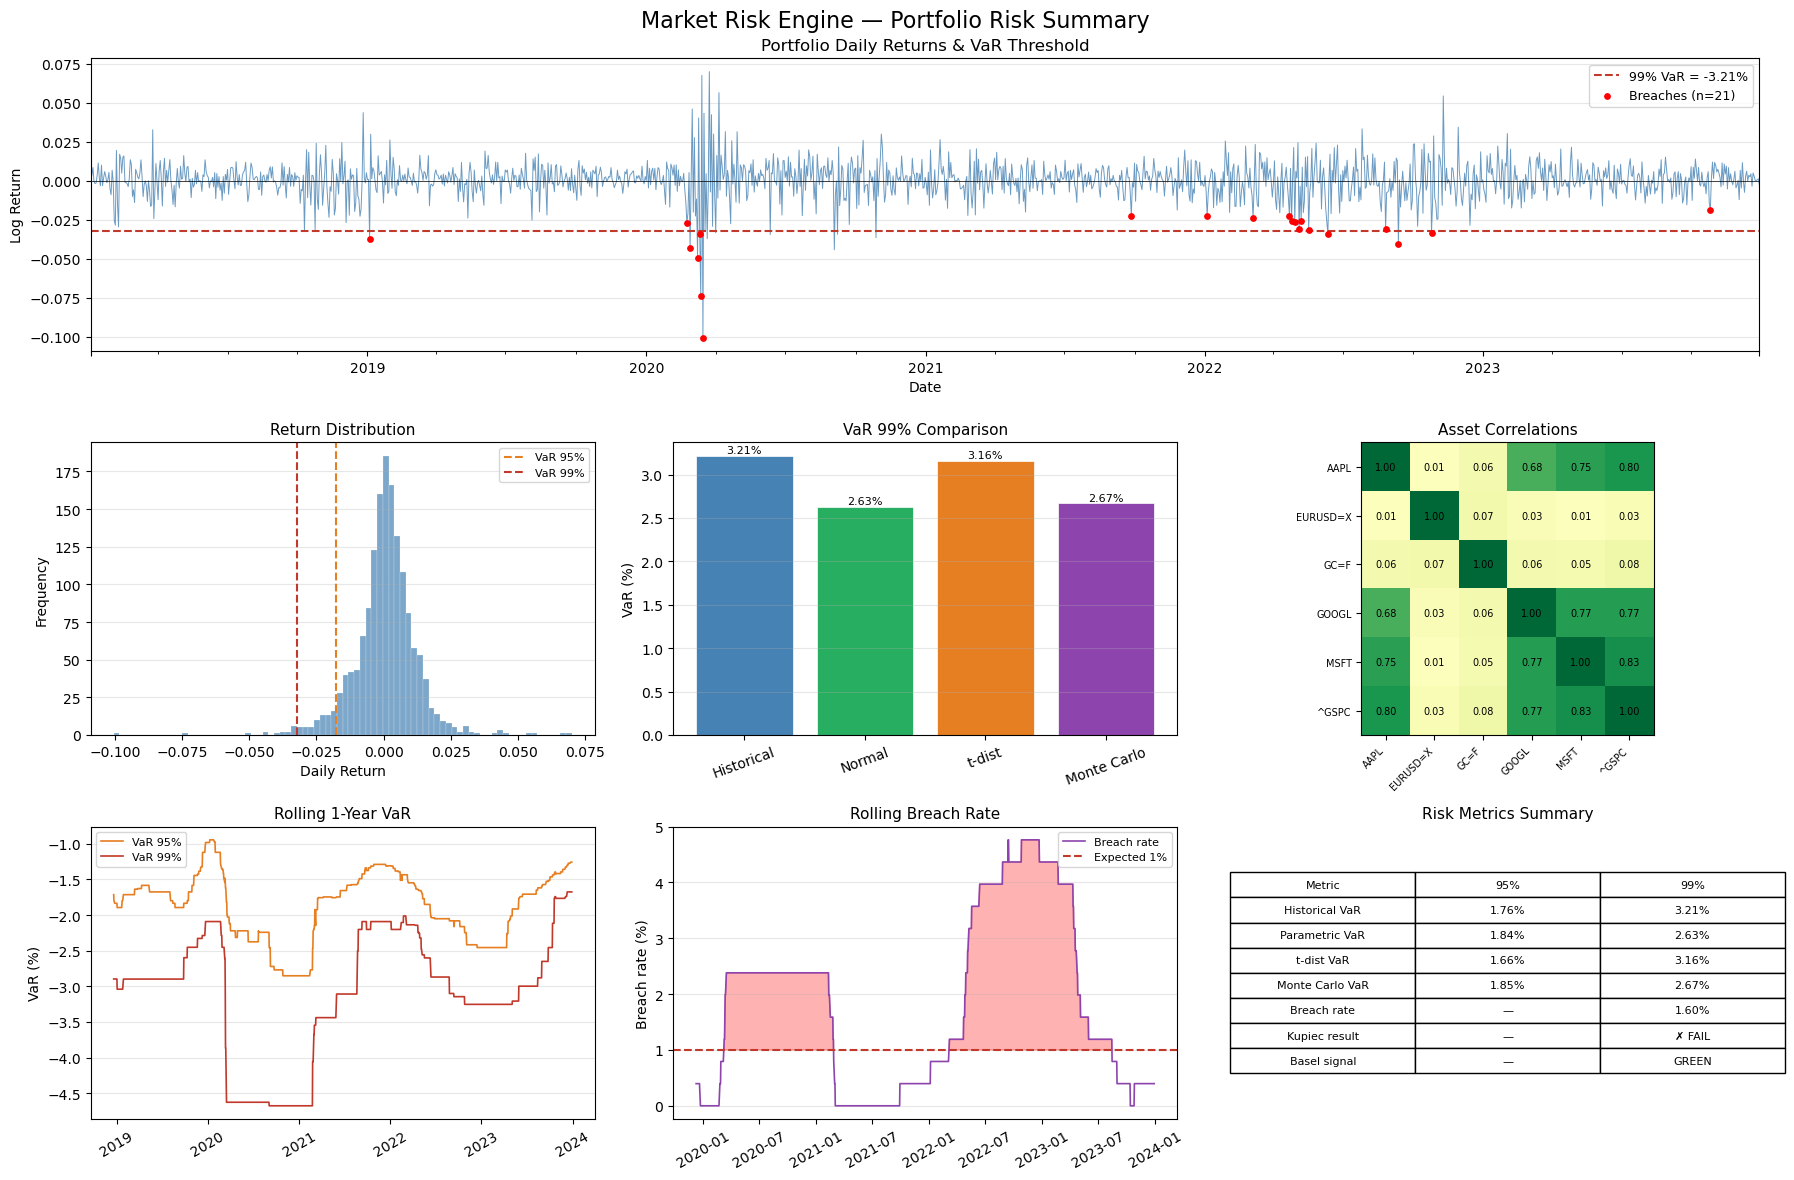

Market-Risk-Engine is fully built


In [25]:
# ── Final Summary Dashboard ───────────────────────────────────────────────────
# One clean figure summarising the entire project
# This is what you screenshot for your README

fig = plt.figure(figsize=(18, 12))
fig.suptitle('Market Risk Engine — Portfolio Risk Summary', fontsize=16, y=0.98)

# ── Panel 1: Portfolio returns time series ────────────────────────────────────
ax1 = fig.add_subplot(3, 3, (1, 3))
portfolio_returns.plot(ax=ax1, color='steelblue', linewidth=0.7, alpha=0.8)
ax1.axhline(var_hist_99, color='#c0392b', linewidth=1.5,
            linestyle='--', label=f'99% VaR = {var_hist_99*100:.2f}%')
ax1.axhline(0, color='black', linewidth=0.5)
exc_plot = backtest_df[backtest_df['exceedance']]
ax1.scatter(exc_plot.index, exc_plot['actual_return'],
            color='red', s=15, zorder=5, label=f'Breaches (n={n_exceedances})')
ax1.set_title('Portfolio Daily Returns & VaR Threshold', fontsize=12)
ax1.set_ylabel('Log Return')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# ── Panel 2: Return distribution ──────────────────────────────────────────────
ax2 = fig.add_subplot(3, 3, 4)
portfolio_returns.plot.hist(ax=ax2, bins=80, color='steelblue',
                             edgecolor='white', linewidth=0.2, alpha=0.7)
ax2.axvline(var_hist_95, color='#e67e22', linewidth=1.5,
            linestyle='--', label='VaR 95%')
ax2.axvline(var_hist_99, color='#c0392b', linewidth=1.5,
            linestyle='--', label='VaR 99%')
ax2.set_title('Return Distribution', fontsize=11)
ax2.set_xlabel('Daily Return')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

# ── Panel 3: VaR comparison ───────────────────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 5)
methods = ['Historical', 'Normal', 't-dist', 'Monte Carlo']
var_99_values = [
    abs(var_hist_99) * 100,
    abs(var_norm_99) * 100,
    abs(var_t_99)    * 100,
    abs(var_mc_99)   * 100,
]
colours = ['steelblue', '#27ae60', '#e67e22', '#8e44ad']
bars = ax3.bar(methods, var_99_values, color=colours, edgecolor='white', linewidth=0.5)
ax3.set_title('VaR 99% Comparison', fontsize=11)
ax3.set_ylabel('VaR (%)')
ax3.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, var_99_values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=8)
ax3.grid(axis='y', alpha=0.3)

# ── Panel 4: Correlation heatmap ──────────────────────────────────────────────
ax4 = fig.add_subplot(3, 3, 6)
im = ax4.imshow(corr_matrix.values, cmap='RdYlGn', vmin=-1, vmax=1)
ax4.set_xticks(range(len(corr_matrix.columns)))
ax4.set_yticks(range(len(corr_matrix.columns)))
ax4.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=7)
ax4.set_yticklabels(corr_matrix.columns, fontsize=7)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        ax4.text(j, i, f'{corr_matrix.values[i,j]:.2f}',
                 ha='center', va='center', fontsize=7)
ax4.set_title('Asset Correlations', fontsize=11)

# ── Panel 5: Rolling VaR ──────────────────────────────────────────────────────
ax5 = fig.add_subplot(3, 3, 7)
rolling_var_95_plot = portfolio_returns.rolling(252).quantile(0.05)
rolling_var_99_plot = portfolio_returns.rolling(252).quantile(0.01)
ax5.plot(rolling_var_95_plot.index, rolling_var_95_plot * 100,
         color='#e67e22', linewidth=1.2, label='VaR 95%')
ax5.plot(rolling_var_99_plot.index, rolling_var_99_plot * 100,
         color='#c0392b', linewidth=1.2, label='VaR 99%')
ax5.set_title('Rolling 1-Year VaR', fontsize=11)
ax5.set_ylabel('VaR (%)')
ax5.legend(fontsize=8)
ax5.grid(axis='y', alpha=0.3)
ax5.tick_params(axis='x', rotation=30)

# ── Panel 6: Backtest breach rate ─────────────────────────────────────────────
ax6 = fig.add_subplot(3, 3, 8)
rolling_breach = backtest_df['exceedance'].rolling(252).mean() * 100
ax6.plot(rolling_breach.index, rolling_breach,
         color='#8e44ad', linewidth=1.2, label='Breach rate')
ax6.axhline(1.0, color='#c0392b', linewidth=1.5,
            linestyle='--', label='Expected 1%')
ax6.fill_between(rolling_breach.index, rolling_breach, 1.0,
                 where=rolling_breach > 1.0, alpha=0.3, color='red')
ax6.set_title('Rolling Breach Rate', fontsize=11)
ax6.set_ylabel('Breach rate (%)')
ax6.legend(fontsize=8)
ax6.grid(axis='y', alpha=0.3)
ax6.tick_params(axis='x', rotation=30)

# ── Panel 7: Risk metrics summary table ───────────────────────────────────────
ax7 = fig.add_subplot(3, 3, 9)
ax7.axis('off')

summary_data = [
    ['Metric',              '95%',                          '99%'],
    ['Historical VaR',      f'{abs(var_hist_95)*100:.2f}%', f'{abs(var_hist_99)*100:.2f}%'],
    ['Parametric VaR',      f'{abs(var_norm_95)*100:.2f}%', f'{abs(var_norm_99)*100:.2f}%'],
    ['t-dist VaR',          f'{abs(var_t_95)*100:.2f}%',    f'{abs(var_t_99)*100:.2f}%'],
    ['Monte Carlo VaR',     f'{abs(var_mc_95)*100:.2f}%',   f'{abs(var_mc_99)*100:.2f}%'],
    ['Breach rate',         '—',                             f'{exceedance_rate*100:.2f}%'],
    ['Kupiec result',       '—',                             kupiec_results['Result'][:6]],
    ['Basel signal',        '—',                             colour],
]

table = ax7.table(cellText=summary_data[1:], colLabels=summary_data[0],
                  loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.1, 1.4)
ax7.set_title('Risk Metrics Summary', fontsize=11)

plt.tight_layout()
plt.show()

print("Market-Risk-Engine is fully built")
